(900, 10)
Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn'],
      dtype='object')
Names               object
Age                float64
Total_Purchase     float64
Account_Manager      int64
Years              float64
Num_Sites          float64
Onboard_date        object
Location            object
Company             object
Churn                int64
dtype: object
              Age  Total_Purchase  Account_Manager       Years   Num_Sites  \
count  900.000000      900.000000       900.000000  900.000000  900.000000   
mean    41.816667    10062.824033         0.481111    5.273156    8.587778   
std      6.127560     2408.644532         0.499921    1.274449    1.764836   
min     22.000000      100.000000         0.000000    1.000000    3.000000   
25%     38.000000     8497.122500         0.000000    4.450000    7.000000   
50%     42.000000    10045.870000         0.000000    5.215000    8.000000   


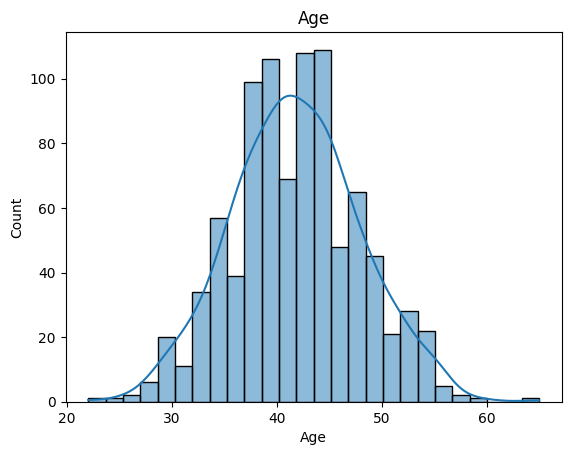

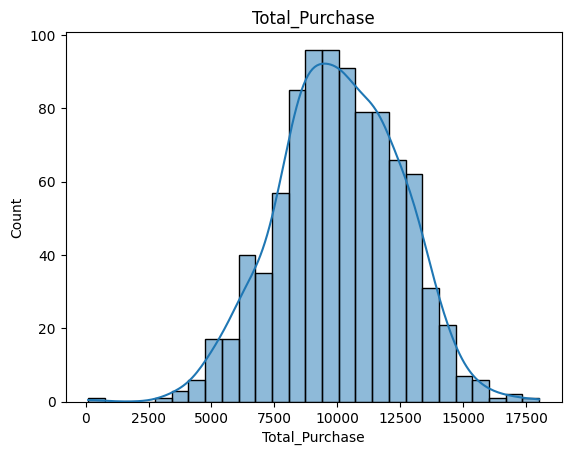

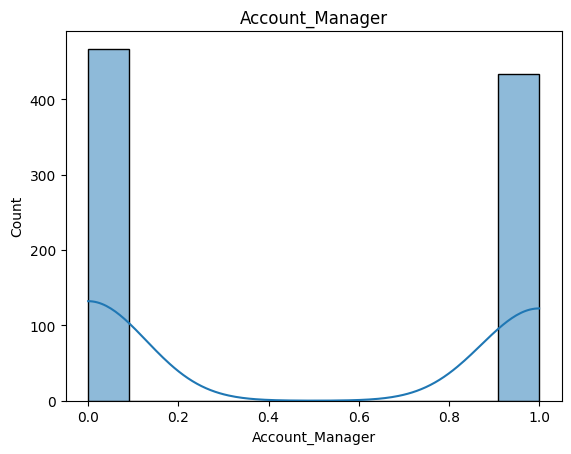

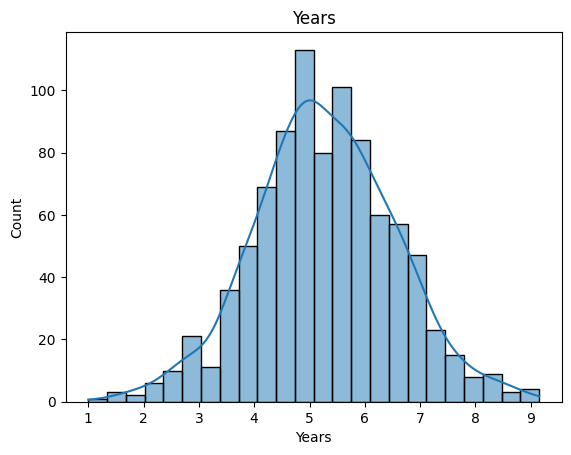

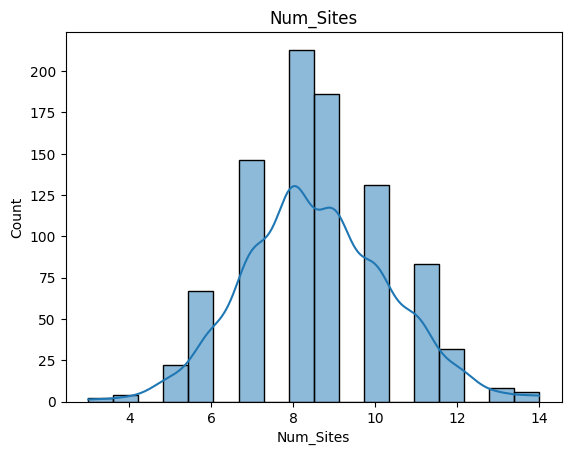

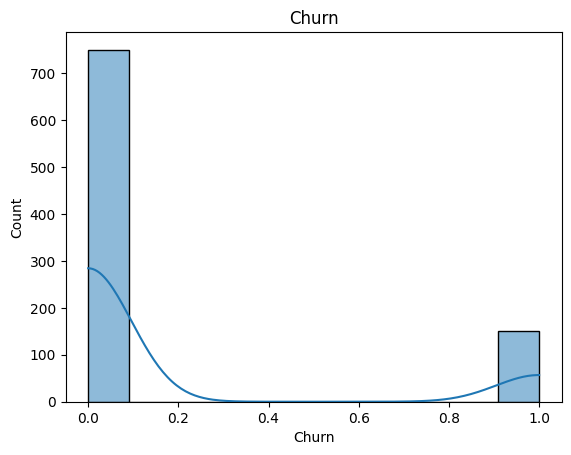

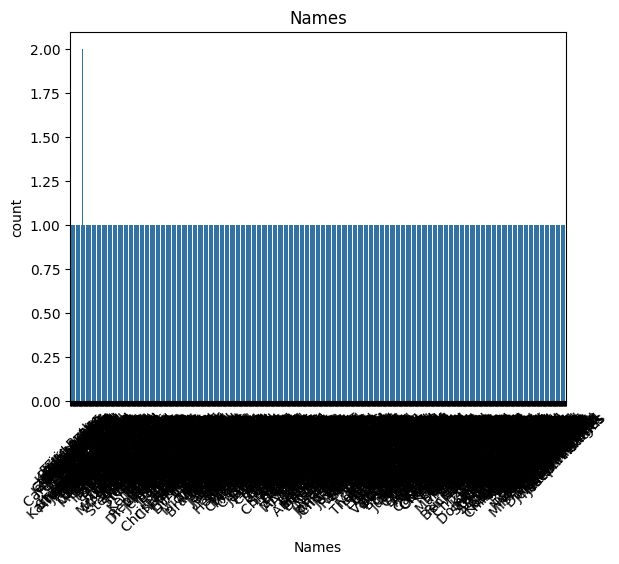

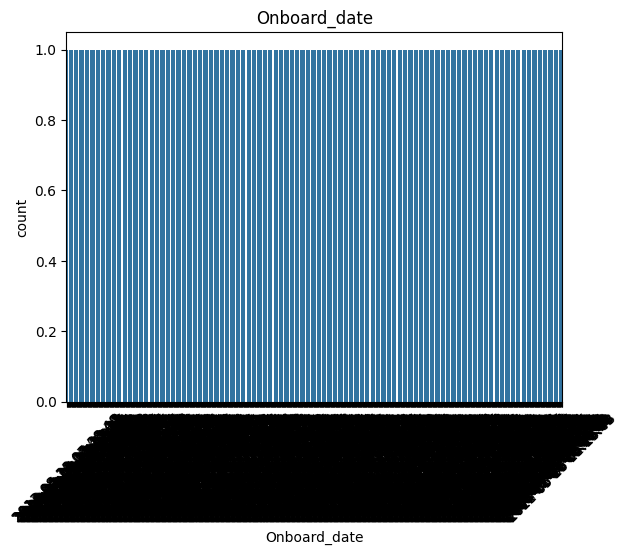

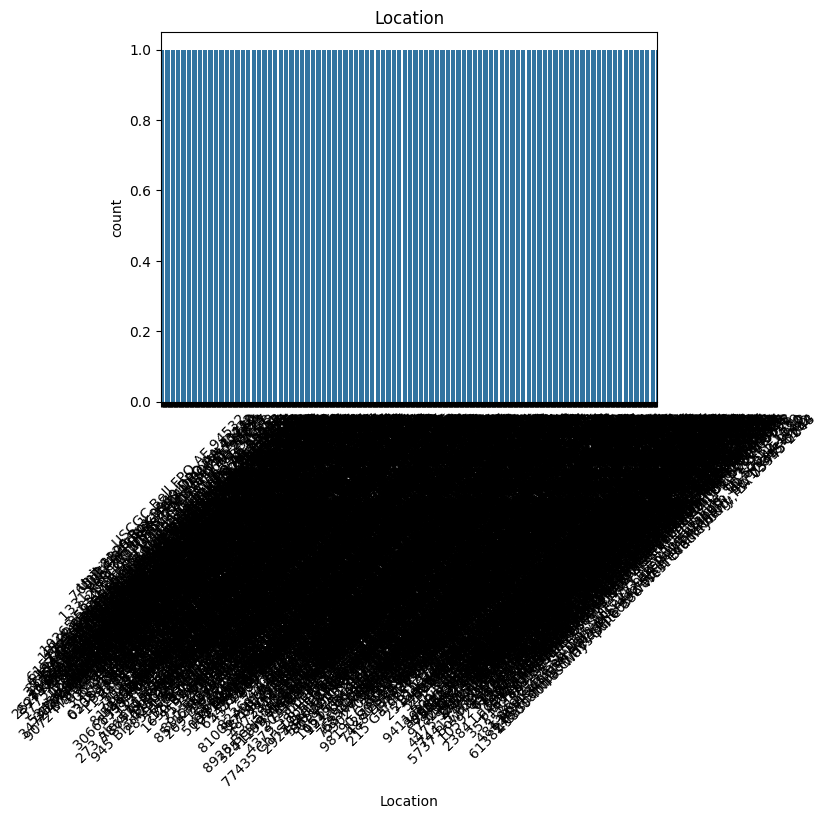

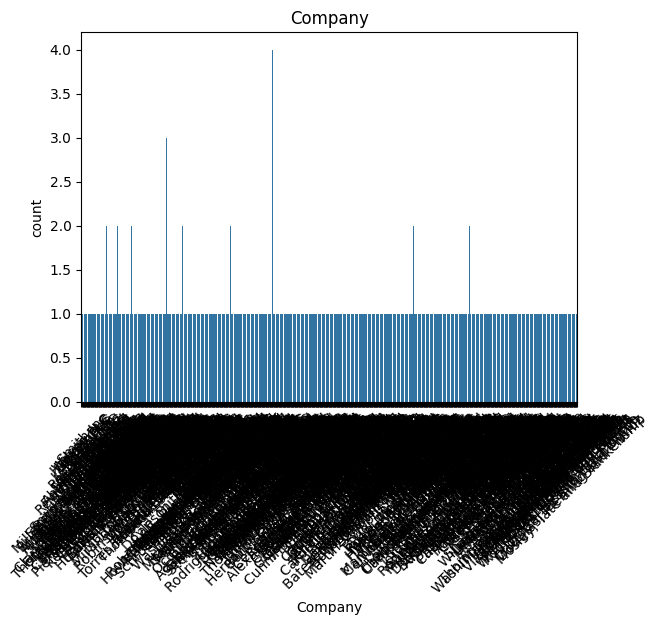

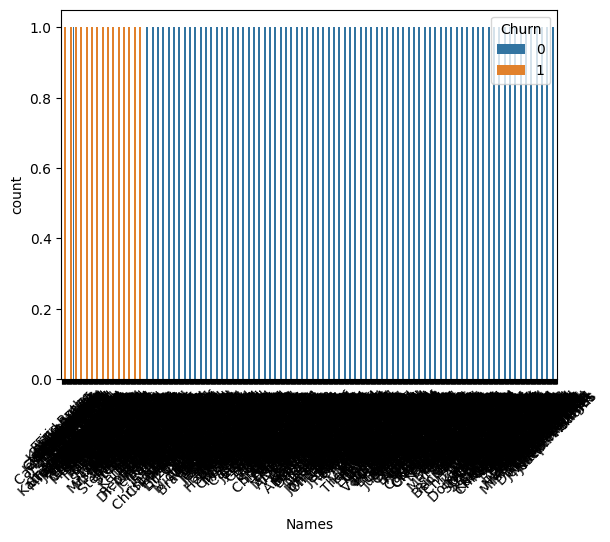

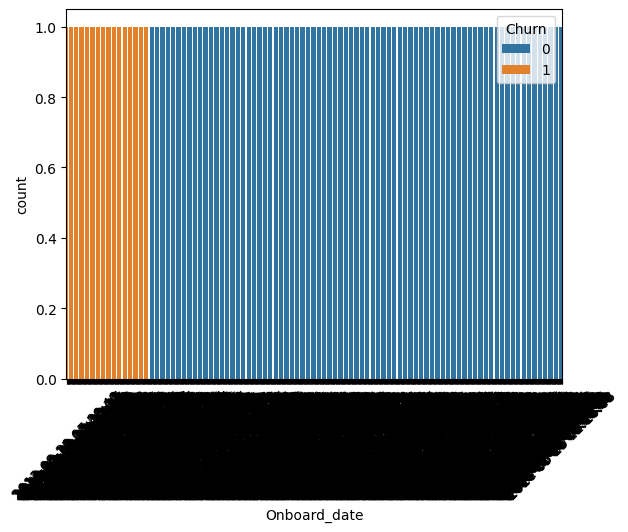

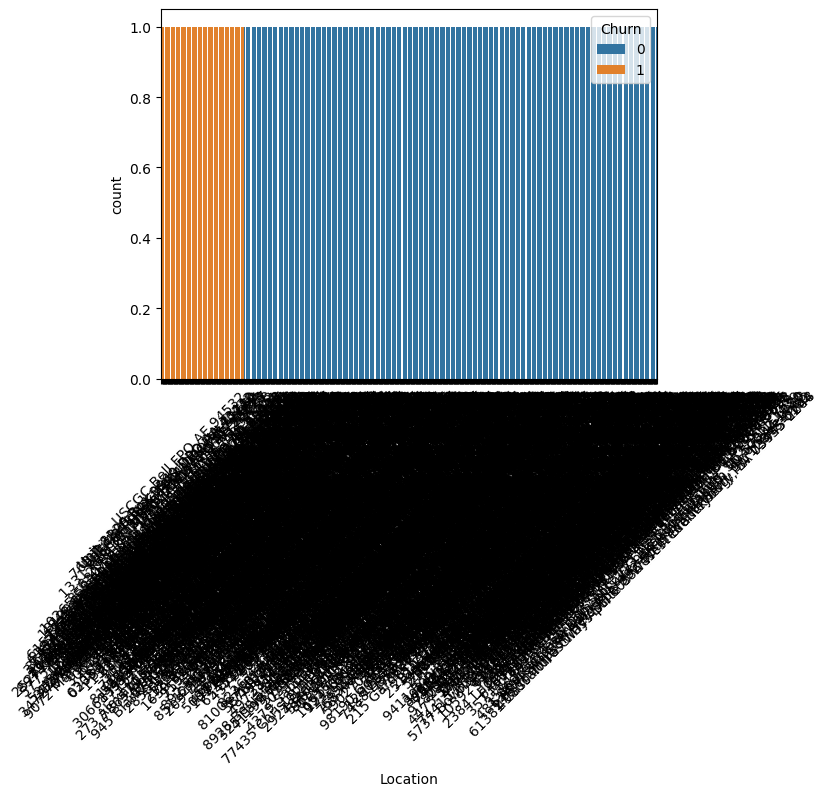

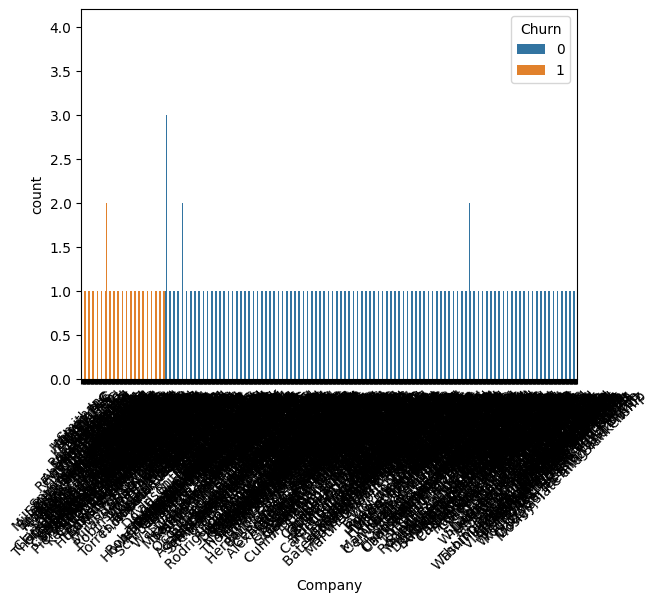

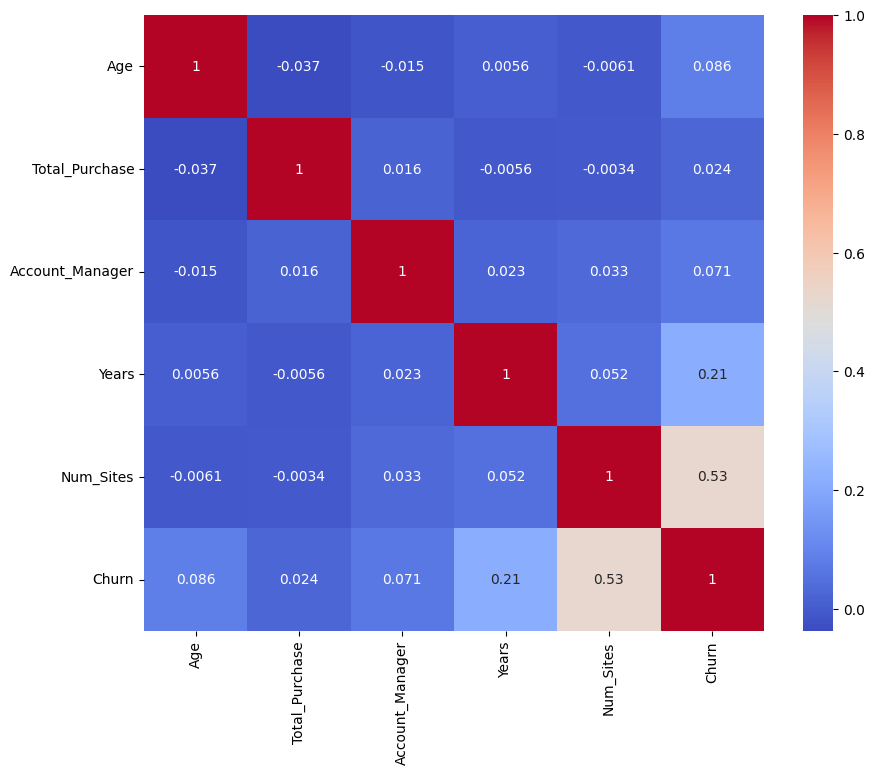

ValueError: The target 'y' needs to have more than 1 class. Got 1 class instead

In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

# 2. Load Dataset
df = pd.read_csv("customer_churn.csv")

# 3. Check Dataset
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.describe())

# 4. Handle Missing Values
df = df.replace(" ", np.nan)
df = df.dropna()

# 5. Remove Duplicates
df = df.drop_duplicates()

# Convert TotalCharges to numeric if exists
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df = df.dropna()

# 6. Univariate Analysis
for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

for col in df.select_dtypes(include='object').columns:
    plt.figure()
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

# 7. Bivariate Analysis
if 'Churn' in df.columns:
    for col in df.select_dtypes(include='object').columns:
        if col != 'Churn':
            plt.figure()
            sns.countplot(x=col, hue='Churn', data=df)
            plt.xticks(rotation=45)
            plt.show()

# 8. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

# 9. Outlier Handling using IQR
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

# 10. Encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# 11. Scaling
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# 12. Separate Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# 13. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 14. Handle Imbalanced Data
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

# 15. Models
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "GradientBoost": GradientBoostingClassifier()
}

results = {}

# 16. Train and Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

    results[name] = acc

    print(name)
    print("Accuracy:", acc)
    print("ROC AUC:", roc)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("------")

# 17. Hyperparameter Tuning (Random Forest example)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# 18. Compare Models
print("Model Comparison:", results)

# 19. Final Model Evaluation
y_pred = best_model.predict(X_test)
print("Best Model Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 20. Final Insights
print("High charges, short tenure, no tech support increase churn")